# Month-End Rebalancing Flows — a quantitative teardown 🔬
### Gap-conditional quintile splits + Welch *t* · a seed-averaged permutation placebo · dose-response, era and window robustness · an expanding-threshold trade with HAC *t* · a planted-reversal synthetic control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![TOM is flows in disguise?: Busted](https://img.shields.io/badge/TOM_is_flows_in_disguise%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim is **conditional** — flows fire when the month-to-date equity-bond gap is big — so the whole design is built to separate a *flow* effect from the desk's known *unconditional* turn-of-the-month drift ([study 89](../../89-turn-of-the-month/), the named sibling and dedup guard).

> ⚠️ **Data note.** SPY + a spliced Aggregate-bond leg — VBMFX before 2003-09-30, AGG after (same Bloomberg Aggregate index; splice in RETURN space, no level stitching; the plan's TLT alternative was rejected for duration mismatch and its 2002 start). Total-return throughout; no survivorship (broad index vehicles). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (as-of **2026-06-30**, fingerprint `3efe1915419d`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from month_end_rebalancing_flows import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    RETS = data.load_real()
    TAB = st.month_table(RETS)
else:
    RETS = TAB = None
print("real cache present:", HAVE_REAL,
      "| months:", (0 if TAB is None else len(TAB)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-02-01', 'end': '2026-06-30', 'n_months': 401, 'n_days': 8410, 'splice': '2003-09-30', 'fingerprint': '3efe1915419d', 'as_of': '2026-06-30', 'sell': {'top_bps': -46.53, 't_top': -2.88, 'bot_bps': 11.58, 't_bot': 0.36, 'uncond_bps': -19.13, 't_uncond': -2.07, 'diff_bps': -58.11, 'welch': -1.6, 'top_vs_uncond': -1.47, 'p_mean': 0.0225, 'p_lo': 0.0175, 'p_hi': 0.03, 'n_top': 81, 'n': 401}, 'rev': {'top_bps': 50.67, 't_top': 2.26, 'bot_bps': 13.96, 't_bot': 0.44, 'uncond_bps': 33.54, 't_uncond': 3.28, 'diff_bps': 36.7, 'welch': 0.95, 'p_mean': 0.1317, 'p_lo': 0.124, 'p_hi': 0.1435, 'n_top': 80, 'n': 400}, 'dose': [(1, -5.32, 11.58, 0.36, 13.96, 0.44), (2, -0.92, 2.22, 0.14, 45.78, 2.0), (3, 1.2, -19.75, -1.19, 29.96, 1.54), (4, 2.87, -43.63, -2.75, 27.33, 1.81), (5, 6.22, -46.45, -2.84, 50.67, 2.26)], 'era': [('1993-2003', -69.18, -1.95, -0.99, -0.01, 3.52, 0.08, -29.92, -0.38), ('2004-2015', -50.99, -2.17, -116.71, -2.14, 135.5, 5.22, 180.14, 3.22), ('2016+', -12.07, -0.57, -50.71, -0.95, -8.54, -0.24, -92.89, -1.52)], 'windows': [(2, -42.39, -2.74, -1.9, 61.18, 3.61, 1.96), (3, -46.53, -2.88, -1.6, 50.67, 2.26, 0.95), (4, -55.51, -3.13, -3.61, 66.1, 2.82, 1.72)], 'trade': [('2 bps/leg, full tape', 70, 1.72, 2.52), ('5 bps/leg, full tape', 70, 1.22, 1.78), ('2 bps, 1993-2015', 46, 2.9, 3.42), ('2 bps, 2016-2026', 26, -0.07, -0.07)], 'trade_gross_pct': 2.06, 'per_event_gross_bps': 98.1, 'per_event_cost_bps': 16, 'share_active_pct': 5.0, 'tom': {'uncond_bps': 34.41, 't_uncond': 3.55, 'mid_bps': 36.35, 't_mid': 3.45, 'top_bps': 43.88, 't_top': 2.05, 'bot_bps': 19.12, 't_bot': 0.64, 'welch_ext_mid': -0.23, 'n_mid': 240, 'n_ext': 160}, 'syn': {'null_mean': -0.04, 'null_sd': 0.59, 'null_max_abs': 1.79, 'null_seeds': 20, 'planted_sell_welch': -9.26, 'planted_rev_welch': 5.66, 'planted_net_pct': 4.35, 'planted_hac': 7.04, 'null_net_pct': 0.04, 'null_hac': 0.07}}


real cache present: True | months: 401


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | *Real on the sell leg:* top-gap-quintile last-3-day spread **-46.53 bps** (one-sample **t = -2.88**), permutation placebo **p ≈ 0.022**, monotone dose-response — but the top-vs-bottom differential reads Welch t = -1.60 on the pre-registered k = 3 window. *Weak on the reversal leg:* Welch t = +0.95, placebo p ≈ 0.13; the first-days pop (+33.54 bps, t = +3.28) is unconditional. |
| **Tradability** | `FRAGILE` | Expanding-threshold trade nets **+1.72%/yr** at 2 bps/leg (HAC **t = +2.52**) — but it is +2.90%/yr (t = 3.42) through 2015 and **-0.07%/yr** since 2016; below the bar at 5 bps (t = 1.78). |
| **TOM in disguise?** | `BUSTED` | Study 89's first-days drift is intact in the middle gap quintiles (**+36.35 bps, t = +3.45**) where rebalancers have nothing to do; extremes-vs-middle Welch t = -0.23. |

> 💡 In plain words: the forced *selling* shows up when the rule says it should; the famous *bounce* shows up whether or not the rule says it should — which means the bounce isn't flows.

## 1 · The claim, steelmanned

Let $g_m$ be month $m$'s equity-minus-bond cumulative-return gap measured through the close 3 trading days before month-end (``gap_pre``, strictly prior to the window it predicts), and $G_m$ the full-month gap (known at the month-end close). Let $S^{last}_m$ and $S^{first}_{m+1}$ be the equity-minus-bond spreads over the last 3 days of $m$ and the first 3 days of $m+1$.

- **H₁ (forced selling).** $E[S^{last}_m \mid g_m \text{ top quintile}] < 0$, and **more negative than** the bottom quintile (the *conditional* fingerprint).
- **H₂ (the reversal).** $E[S^{first}_{m+1} \mid G_m \text{ top quintile}]$ exceeds the bottom quintile — the pressure unwinds.
- **H₃ (tradability).** Fading the winner into month-end and riding the reversal survives costs with an out-of-sample (expanding) threshold.

We find **H₁ half-supported** (the level clears decisively, the top-vs-bottom differential misses at k = 3), **H₂ rejected as a *conditional* claim** (the pop is unconditional TOM), **H₃ supported only pre-2016**.

## 2 · So what? — the inference design

Monthly windows are **non-overlapping**, so quintile splits get plain one-sample and **Welch** *t*'s (no HAC needed there); the daily trade stream *is* serially dependent inside events, so it gets a **Newey-West (5-lag) t** on active days. Two honesty devices:

1. **The permutation placebo** — shuffle the conditioning gap across months (killing the gap→window link, preserving both marginals) and recompute the top-minus-bottom spread. Because a random baseline from one seed is banned on this desk, the p-value is the **mean over 20 seeds × 2,000 draws** (the range is reported).
2. **The dedup guard** — every conditional number is pinned against its unconditional counterpart, because the desk already knows the unconditional month-turn drift is a thing (study 89). A flow story earns nothing for rediscovering the calendar.

## 3 · How we'd know — the protocol

- **Tape.** SPY + spliced VBMFX→AGG bond leg, 1993-02-01 → 2026-06-30 (8,410 sessions, **401 complete months**), total-return, as-of 2026-06-30, fingerprint `3efe1915419d`.
- **Conditioning.** ``gap_pre`` (through the close 3 days before month-end) predicts the last-3 window; ``gap_full`` (month-end close) predicts the first-3 window — the signal always precedes the window: **one execution lag**, everywhere.
- **Primary tests.** Top-vs-bottom-quintile Welch t on each leg's spread; one-sample t per quintile; seed-averaged permutation placebo.
- **Robustness.** Dose-response over all 5 quintiles; era splits (1993–2003 / 2004–2015 / 2016+); window k ∈ {2, 3, 4} (k = 3 pre-registered).
- **Costs.** 8 one-way tickets per event (pair open + 2×-notional month-end flip + close) at 2/5 bps one-way × NAV; the short leg pays 30 bps/yr borrow pro-rata.
- **Control.** A deterministic two-asset world with a planted, tunable gap-conditional reversal; the null must stay quiet across 20 seeds.

## 4 · The teardown

### 4a · The sell-the-winner leg and its placebo

Top-gap months vs bottom-gap months on the last-3-day spread, against the permutation null (reduced draws in-cell; canonical 20 × 2,000 numbers from results.md).

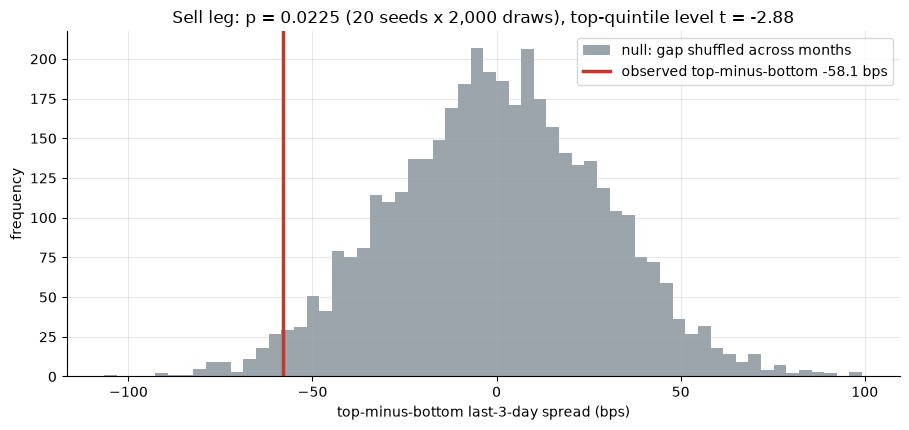

in-cell shuffle: P[diff <= obs] = 0.0227 (canonical 0.0225 [0.0175, 0.0300])


In [2]:
if HAVE_REAL:
    a = st.quintile_split(TAB, 'gap_pre', 'last_spread')
    obs = a['diff_bps']
    # in-cell reduced placebo for the picture (canonical p in R)
    t = TAB.dropna(subset=['gap_pre', 'last_spread']).reset_index(drop=True)
    outv, n = t['last_spread'].values, len(t)
    k = int(np.ceil(n * 0.2)); rng = np.random.default_rng(604)
    draws = []
    for _ in range(4000):
        pr = rng.permutation(n)
        draws.append((outv[pr[-k:]].mean() - outv[pr[:k]].mean()) * 1e4)
    draws = np.array(draws)
else:
    obs = R['sell']['diff_bps']
    rng = np.random.default_rng(604); draws = rng.normal(0, 36, 4000)
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='null: gap shuffled across months')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed top-minus-bottom {obs:+.1f} bps')
ax.set_xlabel('top-minus-bottom last-3-day spread (bps)'); ax.set_ylabel('frequency')
ax.set_title(f"Sell leg: p = {R['sell']['p_mean']:.4f} (20 seeds x 2,000 draws), "
             f"top-quintile level t = {R['sell']['t_top']:+.2f}")
ax.legend(); plt.tight_layout(); plt.show()
print(f"in-cell shuffle: P[diff <= obs] = {(draws <= obs).mean():.4f} "
      f"(canonical {R['sell']['p_mean']:.4f} [{R['sell']['p_lo']:.4f}, {R['sell']['p_hi']:.4f}])")

> 💡 In plain words: the top-gap months' **-46.53 bps** drag (one-sample **t = -2.88**) sits in the left tail of the shuffle null (**p ≈ 0.022**, seed range [0.018, 0.030]) — but note the honest wrinkle: the top-vs-bottom **Welch t = -1.60** misses the desk's 2-bar on the pre-registered 3-day window, because the bottom quintile (+11.6 bps, t = +0.36) is noisy rather than opposite. The level is real; the sharpest conditional contrast is marginal.

### 4b · The reversal leg — conditional or costume?

Same split for the next month's first-3-day spread, with the unconditional mean drawn through it.

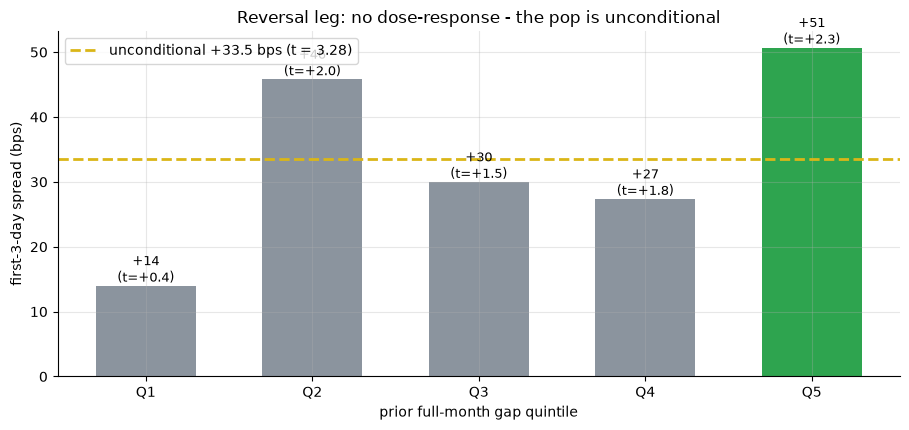

first-3 spread by quintile (bps): [14.0, 45.8, 30.0, 27.3, 50.7]


In [3]:
if HAVE_REAL:
    prof2 = st.quintile_profile(TAB, 'gap_full', 'first_spread')
    vals2 = prof2['mean_bps'].tolist(); ts2 = prof2['t'].tolist()
    unc = float(TAB['first_spread'].mean()) * 1e4
else:
    vals2 = [d[4] for d in R['dose']]; ts2 = [d[5] for d in R['dose']]
    unc = R['rev']['uncond_bps']
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar([f'Q{i}' for i in range(1, 6)], vals2, color=[GREY]*4 + [GREEN], width=.6)
ax.axhline(unc, ls='--', c=AMBER, lw=2, label=f'unconditional {unc:+.1f} bps (t = %.2f)' % R['rev']['t_uncond'])
for i, (vv, tt) in enumerate(zip(vals2, ts2)):
    ax.annotate(f'{vv:+.0f}\n(t={tt:+.1f})', (i, vv), ha='center', va='bottom', fontsize=9)
ax.set_xlabel('prior full-month gap quintile'); ax.set_ylabel('first-3-day spread (bps)')
ax.set_title('Reversal leg: no dose-response - the pop is unconditional')
ax.legend(); plt.tight_layout(); plt.show()
print('first-3 spread by quintile (bps):', [round(x, 1) for x in vals2])

> 💡 In plain words: Q2 (prior month basically flat — nothing to rebalance) pops **+46 bps**, Q5 pops **+51 bps**. Top-vs-bottom Welch **t = +0.95**, placebo **p ≈ 0.13**. The first-days pop (+33.54 bps, **t = +3.28** unconditionally) is a calendar effect, not a flow unwind. H₂ fails *as a conditional claim*.

### 4c · Era and window robustness

The conditional differentials by era (the flow story should strengthen as target-date assets grew — instead it peaks 2004–2015 and dies), and the window length k.

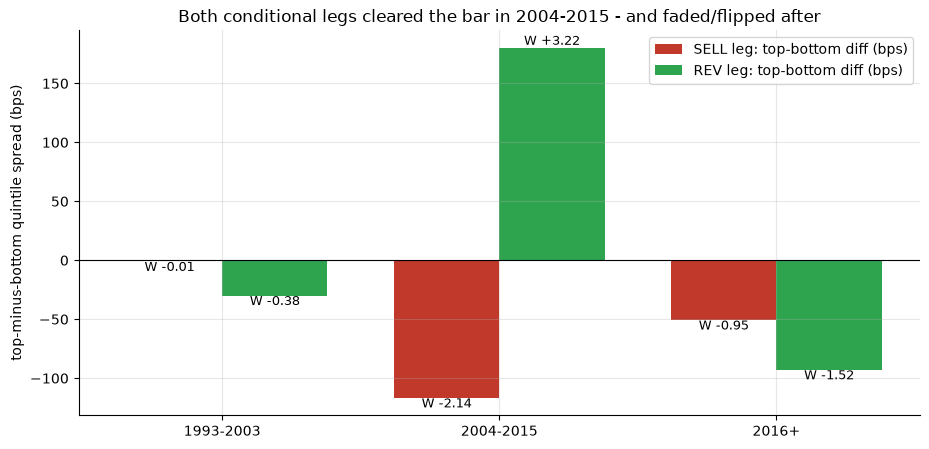

window robustness (k, sell welch, rev welch): [(2, -1.9, 1.96), (3, -1.6, 0.95), (4, -3.61, 1.72)]


In [4]:
eras = R['era']
x = np.arange(len(eras)); w = 0.38
fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.bar(x - w/2, [e[3] for e in eras], w, color=RED, label='SELL leg: top-bottom diff (bps)')
ax.bar(x + w/2, [e[7] for e in eras], w, color=GREEN, label='REV leg: top-bottom diff (bps)')
for i, e in enumerate(eras):
    ax.annotate(f'W {e[4]:+.2f}', (i - w/2, e[3]), ha='center', va='top' if e[3] < 0 else 'bottom', fontsize=9)
    ax.annotate(f'W {e[8]:+.2f}', (i + w/2, e[7]), ha='center', va='bottom' if e[7] > 0 else 'top', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([e[0] for e in eras])
ax.set_ylabel('top-minus-bottom quintile spread (bps)')
ax.set_title('Both conditional legs cleared the bar in 2004-2015 - and faded/flipped after')
ax.legend(); plt.tight_layout(); plt.show()
print('window robustness (k, sell welch, rev welch):', [(k, sw, rw) for k, _, _, sw, _, _, rw in R['windows']])

> 💡 In plain words: 2004–2015 was the flow decade — sell diff **-117 bps (Welch -2.14)**, reversal diff **+180 bps (Welch +3.22)** — and since 2016 the sell leg fades (Welch -0.95) while the reversal **flips sign** (Welch -1.52). Window robustness: the sell-leg *level* clears at every k (t = −2.7 to −3.1); the differential clears only at k = 4 (Welch **-3.61**) — we keep the pre-registered k = 3 headline rather than shop the window.

### 4d · Tradability — the expanding-threshold flow trade

Fire when ``gap_pre`` beats the 80th percentile of all *prior* months (60-month burn-in): short eq/long bd for the last 3 days, flip for the first 3. 8 one-way tickets per event; the short leg pays borrow; HAC t on active days.

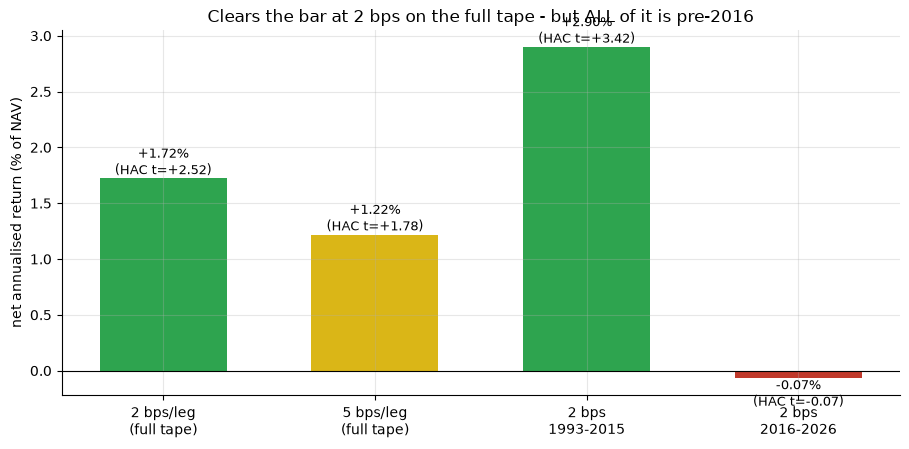

net %/yr and HAC t: [('2 bps/leg (full tape)', 1.72, 2.52), ('5 bps/leg (full tape)', 1.22, 1.78), ('2 bps 1993-2015', 2.9, 3.42), ('2 bps 2016-2026', -0.07, -0.07)]


In [5]:
if HAVE_REAL:
    rows = [st.flow_trade(RETS, cost_bps=cb) for cb in (2.0, 5.0)]
    nets = [r['net_ann_pct'] for r in rows]; hacs = [r['t_net_active'] for r in rows]
else:
    nets = [R['trade'][0][2], R['trade'][1][2]]; hacs = [R['trade'][0][3], R['trade'][1][3]]
labels = ['2 bps/leg\n(full tape)', '5 bps/leg\n(full tape)', '2 bps\n1993-2015', '2 bps\n2016-2026']
vals = nets + [R['trade'][2][2], R['trade'][3][2]]
tvals = hacs + [R['trade'][2][3], R['trade'][3][3]]
colors = [GREEN, AMBER, GREEN, RED]
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.bar(labels, vals, color=colors, width=.6)
for i, (vv, tt) in enumerate(zip(vals, tvals)):
    ax.annotate(f'{vv:+.2f}%\n(HAC t={tt:+.2f})', (i, vv), ha='center',
                va='bottom' if vv >= 0 else 'top', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('net annualised return (% of NAV)')
ax.set_title('Clears the bar at 2 bps on the full tape - but ALL of it is pre-2016')
plt.tight_layout(); plt.show()
print('net %/yr and HAC t:', [(l.replace(chr(10), ' '), round(v, 2), round(t, 2)) for l, v, t in zip(labels, vals, tvals)])

> 💡 In plain words: **+1.72%/yr net** (HAC t = +2.52) at 2 bps/leg, with per-event gross **+98.1 bps** against 16 bps of tickets — but split the tape and the whole P&L is **1993–2015** (+2.90%/yr, t = 3.42); since 2016 it is **-0.07%/yr** (t = -0.07), and 5 bps/leg drops the full tape below the bar (t = 1.78). Real once, decayed → **FRAGILE**.

### 4e · Third axis — is turn-of-the-month just flows in disguise?

The sharpest myth-check this claim allows: if study 89's unconditional TOM drift were rebalancing flows, the first-days equity pop should vanish in months whose prior gap was ≈ 0 (nothing to rebalance) and concentrate in the extremes.

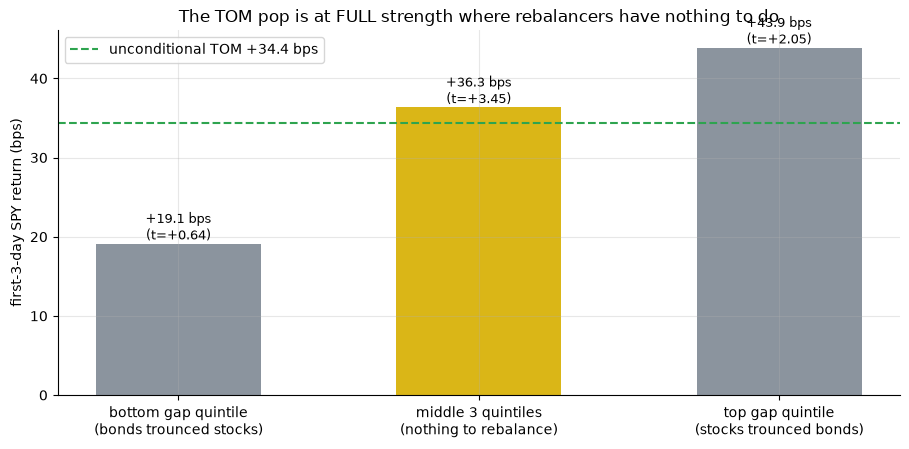

extremes-vs-middle Welch t = -0.23


In [6]:
if HAVE_REAL:
    tv = st.tom_vs_flows(TAB)
else:
    tv = R['tom'].copy(); tv['uncond_bps'] = R['tom']['uncond_bps']
bars = [tv['bot_bps'], tv['mid_bps'], tv['top_bps']]
ts = [tv['t_bot'], tv['t_mid'], tv['t_top']]
labels = ['bottom gap quintile\n(bonds trounced stocks)', 'middle 3 quintiles\n(nothing to rebalance)', 'top gap quintile\n(stocks trounced bonds)']
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.bar(labels, bars, color=[GREY, AMBER, GREY], width=.55)
ax.axhline(tv['uncond_bps'], ls='--', c=GREEN, label=f"unconditional TOM {tv['uncond_bps']:+.1f} bps")
for i, (vv, tt) in enumerate(zip(bars, ts)):
    ax.annotate(f'{vv:+.1f} bps\n(t={tt:+.2f})', (i, vv), ha='center', va='bottom', fontsize=9)
ax.set_ylabel('first-3-day SPY return (bps)')
ax.set_title('The TOM pop is at FULL strength where rebalancers have nothing to do')
ax.legend(); plt.tight_layout(); plt.show()
print(f"extremes-vs-middle Welch t = {tv['welch_ext_vs_mid']:+.2f}")

> 💡 In plain words: the middle quintiles — months with a near-zero gap — still pop **+36.35 bps (t = +3.45)**, statistically identical to the extremes (Welch t = -0.23). Study 89's TOM is a calendar drift with its own engine (payroll/settlement cash, habit), **not** this flow — **BUSTED**, and the two studies genuinely measure different things.

### 4f · Faithful-engine & power control — we know the truth here

A deterministic two-asset random walk with a planted, gap-conditional flow reversal (``edge``). The null (edge = 0) must stay quiet across seeds; the planted world must light up. In-cell we run a reduced seed sweep (canonical 20-seed numbers from results.md).

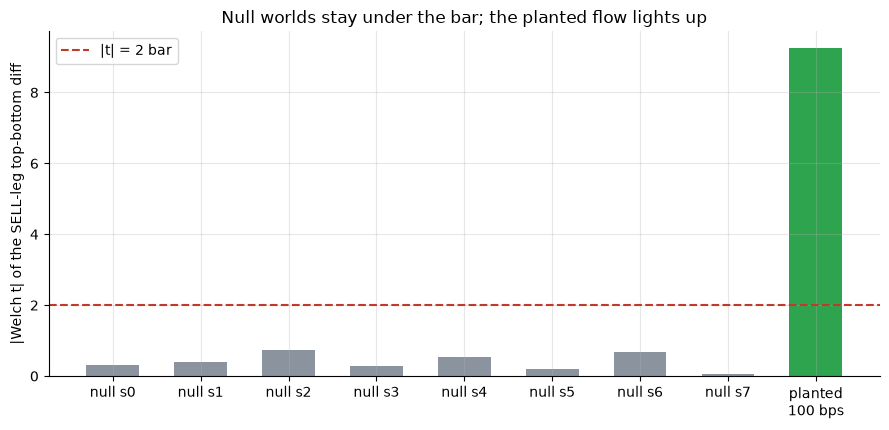

null (8 seeds): mean +0.10, max |t| 0.73 (canonical 20 seeds: mean -0.04, max |t| 1.79)
planted 100 bps: SELL Welch -9.26, REV Welch +5.66 (canonical -9.26 / +5.66)


In [7]:
ws = []
for sd in range(8):                    # reduced sweep; canonical = 20 seeds in R
    w0 = data.synthetic_world(edge=0.0, seed=sd)
    t0 = st.month_table(w0)
    ws.append(st.quintile_split(t0, 'gap_pre', 'last_spread')['welch_t'])
w1 = data.synthetic_world(edge=0.010, seed=604)
t1 = st.month_table(w1)
a1 = st.quintile_split(t1, 'gap_pre', 'last_spread')
b1 = st.quintile_split(t1, 'gap_full', 'first_spread')
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar([f'null s{sd}' for sd in range(8)] + ['planted\n100 bps'],
       [abs(x) for x in ws] + [abs(a1['welch_t'])],
       color=[GREY]*8 + [GREEN], width=.6)
ax.axhline(2, ls='--', c=RED, label='|t| = 2 bar')
ax.set_ylabel('|Welch t| of the SELL-leg top-bottom diff')
ax.set_title('Null worlds stay under the bar; the planted flow lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null (8 seeds): mean {np.mean(ws):+.2f}, max |t| {max(abs(x) for x in ws):.2f} '
      f"(canonical 20 seeds: mean {R['syn']['null_mean']:+.2f}, max |t| {R['syn']['null_max_abs']:.2f})")
print(f"planted 100 bps: SELL Welch {a1['welch_t']:+.2f}, REV Welch {b1['welch_t']:+.2f} "
      f"(canonical {R['syn']['planted_sell_welch']:+.2f} / {R['syn']['planted_rev_welch']:+.2f})")

> 💡 In plain words: across 20 independent null worlds the detector never clears \|t\| = 2 (mean -0.04, max \|t\| = 1.79); a planted 100-bps reversal explodes to Welch **-9.26** / **+5.66** and the trade banks **+4.35%/yr (HAC t = +7.04)** vs +0.04%/yr on the null. The machinery is unbiased and powered. *(A faithful-engine / power check only — never cited to support the real-tape stamps.)*

## 5 · The verdict

- **Signal `MIXED`** — *Real on the sell leg:* top-gap months drag **-46.53 bps** over the last 3 days (one-sample **t = -2.88**, placebo **p ≈ 0.022**, monotone dose-response, level clears at every window k); the purely conditional differential is marginal at k = 3 (Welch -1.60; clears at k = 4 with -3.61). *Weak on the reversal leg:* Welch +0.95, placebo p ≈ 0.13 — the pop is unconditional TOM. No survivorship (broad index vehicles).
- **Tradability `FRAGILE`** — +1.72%/yr net at 2 bps/leg (HAC t = +2.52), all of it earned 1993–2015 (+2.90%/yr, t = 3.42); -0.07%/yr since 2016; below the bar at 5 bps. Real once, decayed.
- **TOM in disguise? `BUSTED`** — the drift survives at full strength (+36.35 bps, t = +3.45) precisely where there is nothing to rebalance (extremes-vs-middle Welch t = -0.23).

## 6 · Going further

- **Sharper conditioning.** The gap is the folklore's own variable; dollar-weighted versions (gap × balanced-fund AUM), quarter-end-only, or vol-scaled drift are the obvious next knobs — the ``month_table`` conditioning column is pluggable.
- **Why 2004–2015?** Balanced/TDF assets grew all the way through 2026, yet the effect died in 2016 — consistent with McLean-Pontiff-style *crowding of the trade against the flow* (every desk now front-runs the rebalancers), not with the flow disappearing.
- **The dedup lesson.** Conditioning is what separates a *flow* claim from a *calendar* claim — and on this tape the famous reversal half belongs to the calendar ([89-turn-of-the-month](../../89-turn-of-the-month/)), while only the selling half belongs to the flows.

*The reproducible core is offline and deterministic; every number above is printed by [`examples/verify.py`](../examples/verify.py) and frozen in [`docs/results.md`](../docs/results.md).*